In [ ]:
%%capture
%pip install lightning adversarial-robustness-toolbox[pytorch_image] umap-learn tsnecuda==3.0.1+cu122 -f https://tsnecuda.isx.ai/tsnecuda_stable.html

# Libraries

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals, annotations
from abc import ABC, abstractmethod
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any, Callable, TYPE_CHECKING
from dataclasses import dataclass

import h5py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import *
import umap

from tqdm.notebook import tqdm

from einops import rearrange
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms
import torchvision.models as models
import torchmetrics

import art
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent
from art.estimators.classification import PyTorchClassifier
from art.config import ART_NUMPY_DTYPE
from art.defences.preprocessor import *
from art.defences.preprocessor.preprocessor import Preprocessor

if TYPE_CHECKING:
    from art.utils import CLIP_VALUES_TYPE

from lightning import LightningModule

# Dataset

In [15]:
class PCAMDataset(Dataset):
    """Optimized PCAM Dataset with lazy loading"""
    
    def __init__(self, input_file_path: str, label_file_path: str, 
                 transform=None, max_samples: Optional[int] = None):
        self.input_file_path = input_file_path
        self.label_file_path = label_file_path
        self.transform = transform
        self.max_samples = max_samples
        
        # Open files and keep references
        self.input_file = h5py.File(self.input_file_path, 'r')
        self.label_file = h5py.File(self.label_file_path, 'r')
        
        self.input_data = self.input_file["x"]
        self.label_data = self.label_file["y"]
        
        # Set length
        self.length = len(self.input_data)
        if max_samples is not None:
            self.length = min(max_samples, self.length)
            print(f"Using {max_samples}/{len(self.input_data)} samples")
            
    def __len__(self) -> int:
        return self.length
    
    def __getitem__(self, idx: int):
        if idx >= self.length:
            raise IndexError("Index out of range")
        
        # Load image and convert to PIL
        image = Image.fromarray(self.input_data[idx]).convert("RGB")
        label = int(self.label_data[idx, 0, 0, 0])
        
        if self.transform:
            image = self.transform(image)
            
        return image, label
    
    def __del__(self):
        # Close files when dataset is destroyed
        if hasattr(self, 'input_file'):
            self.input_file.close()
        if hasattr(self, 'label_file'):
            self.label_file.close()

# ResNet18 Classifier

In [16]:
class ResNet18Classifier(LightningModule):
    def __init__(self, num_classes: int = 2, label_smoothing: float = 0.0):
        super().__init__()
        self.model = models.resnet18(weights='DEFAULT')
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)
        self.num_classes = num_classes
        
        self.criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

        self.train_acc = torchmetrics.Accuracy("binary", num_classes=num_classes)
        self.train_auroc = torchmetrics.AUROC("binary", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy("binary", num_classes=num_classes)
        self.val_auroc = torchmetrics.AUROC("binary", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy("binary", num_classes=num_classes)
        self.test_auroc = torchmetrics.AUROC("binary", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def _step(self, batch, stage: str):
        images, labels = batch

        outputs = self(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        probs = F.softmax(outputs, dim=1)

        if stage == "train":
            self.train_acc(preds, labels)
            self.train_auroc(probs, labels)
        elif stage == "val":
            self.val_acc(preds, labels)
            self.val_auroc(probs, labels)
        elif stage == "test":
            self.test_acc(preds, labels)
            self.test_auroc(probs, labels)
        else:
            raise ValueError(f"Unknown stage: {stage}")
        
        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=True)        
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, "train")
    def validation_step(self, batch, batch_idx):
        return self._step(batch, "val")
    def test_step(self, batch, batch_idx):
        return self._step(batch, "test")

    def on_train_epoch_end(self):
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_auroc", self.train_auroc, on_step=False, on_epoch=True, prog_bar=True)
        self.train_acc.reset()
        self.train_auroc.reset()
    
    def on_validation_epoch_end(self):
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_auroc", self.val_auroc, on_step=False, on_epoch=True, prog_bar=True)
        self.val_acc.reset()
        self.val_auroc.reset()

    def on_test_epoch_end(self):
        self.log("test_acc", self.test_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_auroc", self.test_auroc, on_step=False, on_epoch=True, prog_bar=True)
        self.test_acc.reset()
        self.test_auroc.reset()

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=1e-3, weight_decay=0.05)
        
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.1, patience=5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1,
            },
        }
        
    def freeze_backbone(self):
        for param in self.model.parameters():
            param.requires_grad = False
        for param in self.model.fc.parameters():  # Keep classifier trainable
            param.requires_grad = True

    def unfreeze_backbone(self):
        for param in self.model.parameters():
            param.requires_grad = True

## Configuration

In [ ]:
# Configuration
DATA_ROOT = "/kaggle/input/metastatic-tissue-classification-patchcamelyon"
MODEL_PATH = "/kaggle/input/hermes_resnet_18/pytorch/lightning/1/reduced_dataset_10ep.ckpt"

BATCH_SIZE = 512

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [18]:
# Data transforms
eval_transform = transforms.Compose([
    transforms.ToTensor(), # here they become [0, 1] due to torch backend with Pillow
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [19]:
# Load dataset
print("Loading test dataset...")
test_dataset = PCAMDataset(
    input_file_path=os.path.join(DATA_ROOT, "pcam/test_split.h5"),
    label_file_path=os.path.join(DATA_ROOT, "Labels/Labels/camelyonpatch_level_2_split_test_y.h5"),
    transform=eval_transform,
    max_samples=5000  # Reduced for faster evaluation
)

Loading test dataset...
Using 5000/32768 samples


In [20]:
# Load model
print("Loading model...")
model = ResNet18Classifier.load_from_checkpoint(MODEL_PATH)

Loading model...


In [21]:
class GaussianSmoothing(Preprocessor):
    params = ["sigma", "verbose"]

    def __init__(
        self,
        clip_values: "CLIP_VALUES_TYPE" | None = None,
        sigma: float = 1.0,
        apply_fit: bool = True,
        apply_predict: bool = True,
        verbose: bool = False,
    ):
        """
        Some description of the class
        """
        super().__init__(is_fitted=True, apply_fit=apply_fit, apply_predict=apply_predict)
        self.sigma = sigma
        self.clip_values = clip_values
        self.verbose = verbose
        self._check_params()

    def __call__(self, x: np.ndarray, y: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray | None]:

        x_aug = np.random.normal(x, scale=self.sigma, size=x.shape).astype(ART_NUMPY_DTYPE)
        y_aug = y
        
        if self.clip_values is not None:
            x_aug = np.clip(x_aug, self.clip_values[0], self.clip_values[1])

        return x_aug, y_aug
        
    def _check_params(self) -> None:
        if not isinstance(self.sigma, float) or self.sigma <= 0:
            raise ValueError("Smoothing sigma must be a positive float.")

        if self.clip_values is not None:

            if len(self.clip_values) != 2:
                raise ValueError(
                    "`clip_values` should be a tuple of 2 floats or arrays containing the allowed data range."
                )
            if np.array(self.clip_values[0] >= self.clip_values[1]).any():
                raise ValueError("Invalid `clip_values`: min >= max.")

In [22]:
@dataclass
class ExperimentResult:
    """Data class to represent a single experiment result."""
    attack: str
    defense: str
    accuracy: float
    details: Optional[Dict] = None

class ExperimentState:
    """Manages the state of experiments to avoid recomputation."""
    
    def __init__(self):
        self.adversarial_datasets: Dict[str, Dataset] = {}
        self.prediction_data: Dict[str, Tuple[float, Dict]] = {}
        self.detailed_results: Dict[str, Dict] = {}
    
    def has_adversarial_dataset(self, attack_name: str) -> bool:
        return attack_name in self.adversarial_datasets
    
    def get_adversarial_dataset(self, attack_name: str) -> Optional[Dataset]:
        return self.adversarial_datasets.get(attack_name)
    
    def store_adversarial_dataset(self, attack_name: str, dataset: Dataset):
        self.adversarial_datasets[attack_name] = dataset
    
    def has_predictions(self, key: str) -> bool:
        return key in self.prediction_data
    
    def get_predictions(self, key: str) -> Optional[Tuple[float, Dict]]:
        return self.prediction_data.get(key)
    
    def store_predictions(self, key: str, accuracy: float, details: Dict):
        self.prediction_data[key] = (accuracy, details)

In [23]:
class UnNormalize(torch.nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = torch.tensor(mean).view(3,1,1)
        self.std  = torch.tensor(std ).view(3,1,1)
    
    def forward(self, tensor):
        # tensor is C×H×W, normalized
        return tensor * self.std + self.mean

class Rescale01(torch.nn.Module):
    """Rescale C×H×W tensor so its min→0 and max→1."""
    def forward(self, t):
        tmin, tmax = float(t.min()), float(t.max())
        if tmax <= tmin:
            return torch.zeros_like(t)
        return (t - tmin) / (tmax - tmin)

class TransformedDataset(Dataset):
    """Small wrapper to apply transform and do unnorm + 0-1 minmax scaling"""
    def __init__(self, base_dataset: Dataset, transform: Callable):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]           # x: torch.Tensor C×H×W
        x_t = self.transform(x)
        return x_t, y

In [24]:
class DefenseStrategy(ABC):
    """Abstract base class for defense strategies."""
    
    @abstractmethod
    def prepare_dataset(self, dataset: Dataset) -> Dataset:
        """Prepare the dataset for this specific defense."""
        pass
    
    @abstractmethod
    def is_supported(self) -> bool:
        """Check if this defense strategy is currently supported."""
        pass

class StandardDefenseStrategy(DefenseStrategy):
    """Standard defense that works with datasets as-is."""
    
    def prepare_dataset(self, dataset: Dataset) -> Dataset:
        return dataset
    
    def is_supported(self) -> bool:
        return True

class JPEGDefenseStrategy(DefenseStrategy):
    """JPEG compression defense that requires special preprocessing."""
    
    def __init__(self, imagenet_mean, imagenet_std):
        self.imagenet_mean = imagenet_mean
        self.imagenet_std = imagenet_std
    
    def prepare_dataset(self, dataset: Dataset) -> Dataset:
        
        unnorm = UnNormalize(self.imagenet_mean, self.imagenet_std)
        jpeg_preproc = transforms.Compose([
            unnorm,
            Rescale01(),
        ])
        return TransformedDataset(dataset, jpeg_preproc)
    
    def is_supported(self) -> bool:
        return True

class MP3DefenseStrategy(DefenseStrategy):
    """MP3 compression defense (not yet implemented)."""
    
    def prepare_dataset(self, dataset: Dataset) -> Dataset:
        raise NotImplementedError(
            "MP3 compression defense is not implemented yet. "
            "The main issue is that you need to convert the image tensor to "
            "downsampling the number of channels to 1 or 2 (mono/stereo) and "
            "then apply the MP3 compression by flattening H and W dimensions. "
            "But then you need to reshape it back to C×H×W, while having only 1 or 2 channels."
        )
    
    def is_supported(self) -> bool:
        return False

class DefenseStrategyFactory:
    """Factory to create appropriate defense strategies."""
    
    def __init__(self, imagenet_mean=IMAGENET_MEAN, imagenet_std=IMAGENET_STD):
        self.imagenet_mean = imagenet_mean
        self.imagenet_std = imagenet_std
    
    def create_strategy(self, defense_name: str) -> DefenseStrategy:
        """Create the appropriate defense strategy based on the defense name."""
        if 'jpeg' in defense_name.lower():
            if self.imagenet_mean is None or self.imagenet_std is None:
                raise ValueError("ImageNet mean and std required for JPEG defense")
            return JPEGDefenseStrategy(self.imagenet_mean, self.imagenet_std)
        elif 'mp3' in defense_name.lower():
            return MP3DefenseStrategy()
        else:
            return StandardDefenseStrategy()

In [25]:
class ExperimentRunner:
    """Handles the execution of individual experiments."""
    
    def __init__(self, framework: 'MyFramework', state: ExperimentState):
        self.framework = framework
        self.state = state
        self.defense_factory = DefenseStrategyFactory()
    
    def run_clean_experiment(self) -> ExperimentResult:
        """Run experiment on clean data."""
        key = "clean"
        if self.state.has_predictions(key):
            accuracy, details = self.state.get_predictions(key)
            print(f"Using cached results for {key}")
        else:
            print(f"Computing results for {key}")
            accuracy, details = self.framework._evaluate_dataset(
                self.framework.test_dataset, 
                self.framework.base_classifier, 
                name="clean"
            )
            self.state.store_predictions(key, accuracy, details)
        
        return ExperimentResult(attack="none", defense="none", accuracy=accuracy, details=details)
    
    def run_attack_experiment(self, attack_name: str, attack_fn: Callable) -> List[ExperimentResult]:
        """Run experiments for a single attack with all defenses."""
        results = []
        
        # Generate or retrieve adversarial dataset
        adv_dataset = self._get_or_generate_adversarial_dataset(attack_name, attack_fn)
        
        # Test attack without defense
        no_defense_result = self._evaluate_attack_without_defense(attack_name, adv_dataset)
        results.append(no_defense_result)
        
        # Test attack with each defense
        defense_results = self._evaluate_attack_with_defenses(attack_name, adv_dataset)
        results.extend(defense_results)
        
        return results
    
    def _get_or_generate_adversarial_dataset(self, attack_name: str, attack_fn: Callable) -> Dataset:
        """Get existing adversarial dataset or generate a new one."""
        if self.state.has_adversarial_dataset(attack_name):
            print(f"Using cached adversarial dataset for {attack_name}")
            return self.state.get_adversarial_dataset(attack_name)
        
        print(f"Generating adversarial dataset for {attack_name}")
        adv_dataset, details = self.framework._generate_adversarial_dataset(
            self.framework.base_classifier, attack_fn, attack_name
        )
        self.state.store_adversarial_dataset(attack_name, adv_dataset)
        return adv_dataset
    
    def _evaluate_attack_without_defense(self, attack_name: str, adv_dataset: Dataset) -> ExperimentResult:
        """Evaluate attack without any defense."""
        key = f"{attack_name}_no_defense"
        if self.state.has_predictions(key):
            accuracy, details = self.state.get_predictions(key)
            print(f"Using cached results for {key}")
        else:
            print(f"Computing results for {key}")
            accuracy, details = self.framework._evaluate_dataset(
                adv_dataset, self.framework.base_classifier, name=key
            )
            self.state.store_predictions(key, accuracy, details)
        
        return ExperimentResult(attack=attack_name, defense="none", accuracy=accuracy, details=details)
    
    def _evaluate_attack_with_defenses(self, attack_name: str, adv_dataset: Dataset) -> List[ExperimentResult]:
        """Evaluate attack with all registered defenses."""
        results = []
        
        for defense_name, defense_fn in self.framework.defenses:
            try:
                result = self._evaluate_single_defense(attack_name, defense_name, defense_fn, adv_dataset)
                results.append(result)
            except NotImplementedError as e:
                print(f"Skipping {defense_name}: {e}")
                continue
        
        return results
    
    def _evaluate_single_defense(
        self, 
        attack_name: str, 
        defense_name: str, 
        defense_fn: Callable, 
        adv_dataset: Dataset
    ) -> ExperimentResult:
        """Evaluate a single defense against an attack."""
        key = f"{attack_name}_{defense_name}"
        
        if self.state.has_predictions(key):
            accuracy, details = self.state.get_predictions(key)
            print(f"Using cached results for {key}")
            return ExperimentResult(attack=attack_name, defense=defense_name, accuracy=accuracy, details=details)
        
        print(f"Computing results for {key}")
        
        # Create defense strategy and prepare dataset
        strategy = self.defense_factory.create_strategy(defense_name)
        if not strategy.is_supported():
            raise NotImplementedError(f"Defense {defense_name} is not supported")
        
        prepared_dataset = strategy.prepare_dataset(adv_dataset)
        
        # Build classifier with defense
        classifier_with_defense = self.framework._build_classifier(defences=[defense_fn()])
        
        # Evaluate
        accuracy, details = self.framework._evaluate_dataset(
            prepared_dataset, classifier_with_defense, name=key
        )
        
        self.state.store_predictions(key, accuracy, details)
        return ExperimentResult(attack=attack_name, defense=defense_name, accuracy=accuracy, details=details)

In [26]:
class ResultsManager:
    """Handles saving and loading of experiment results."""
    
    @staticmethod
    def save_results(results: List[ExperimentResult], output_file: str) -> pd.DataFrame:
        """Save results to CSV file."""
        output_path = Path(output_file)
        if output_path.suffix != '.csv':
            raise ValueError("Output file must be a CSV file.")
        
        # Convert results to DataFrame
        data = [
            {"attack": r.attack, "defense": r.defense, "accuracy": r.accuracy}
            for r in results
        ]
        df = pd.DataFrame(data)
        
        # Save to file
        df.to_csv(str(output_path.absolute()), index=False, float_format='%.4f')
        print(f"Results saved to {output_path.absolute()}")
        
        return df

In [27]:
class MyFramework:
    """
    Modular framework for evaluating ART attacks and defenses witha simple OOP design.
    """
    def __init__(
        self,
        model: torch.nn.Module,
        test_dataset: torch.utils.data.Dataset,
        loss: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        input_shape: Tuple[int, int, int],
        num_classes: int,
        channels_first: bool,
        class_names: Optional[List[str]] = None,
        clip_values: Optional[Tuple[int, int]] = None,
        batch_size: int = 64
    ):
        # Core attributes
        self.model = model
        self.test_dataset = test_dataset
        self.loss = loss
        self.optimizer = optimizer
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.channels_first = channels_first
        self.clip_values = clip_values
        self.batch_size = batch_size
        self.class_names = class_names or [f"Class_{i}" for i in range(num_classes)]

        # Instantiate base classifier without defenses
        self.base_classifier = self._build_classifier(defences=None)

        # Registries for attacks and defenses
        self.attacks: List[Tuple[str, Callable]] = []
        self.defenses: List[Tuple[str, Callable]] = []

        # State management
        self.state = ExperimentState()
        
        # Experiment runner
        self.runner = ExperimentRunner(self, self.state)

    def _build_classifier(self, defences: Optional[List[Any]] = None):
        """Return a new PyTorchClassifier with optional preprocessing defenses."""
        from art.estimators.classification import PyTorchClassifier
        return PyTorchClassifier(
            model=self.model,
            loss=self.loss,
            optimizer=self.optimizer,
            input_shape=self.input_shape,
            nb_classes=self.num_classes,
            channels_first=self.channels_first,
            clip_values=self.clip_values,
            preprocessing_defences=defences
        )

    def _make_dataloader(self, dataset: torch.utils.data.Dataset) -> DataLoader:
        """Create a DataLoader for the given dataset."""
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=False,
            pin_memory=True
        )

    def _generate_adversarial_dataset(
        self,
        classifier,
        attack_fn: Callable,
        attack_name: str
    ) -> Tuple[Dataset, Dict]:
        """Generate adversarial examples and collect detailed metrics."""
        attack = attack_fn(classifier)
        loader = self._make_dataloader(self.test_dataset)

        adv_images, adv_labels = [], []
        original_images, perturbations = [], []
        original_preds, adv_preds = [], []
        original_confs, adv_confs = [], []

        for X, y in tqdm(loader, desc=f"Crafting adversarial ({attack.__class__.__name__})"):
            # Generate adversarial examples
            x_adv = attack.generate(x=X.numpy())
            
            # Get predictions and confidences
            orig_pred_probs = classifier.predict(X.numpy())
            adv_pred_probs = classifier.predict(x_adv)
            
            # Store data
            adv_images.append(x_adv)
            adv_labels.append(y)
            original_images.append(X.numpy())
            perturbations.append(x_adv - X.numpy())
            
            original_preds.append(orig_pred_probs.argmax(axis=1))
            adv_preds.append(adv_pred_probs.argmax(axis=1))
            original_confs.append(orig_pred_probs.max(axis=1))
            adv_confs.append(adv_pred_probs.max(axis=1))

        # Concatenate all data
        X_adv = np.concatenate(adv_images, axis=0)
        y_adv = torch.cat(adv_labels)
        X_orig = np.concatenate(original_images, axis=0)
        perturbations_all = np.concatenate(perturbations, axis=0)
        
        # Create detailed results dictionary
        details = {
            'original_images': X_orig,
            'adversarial_images': X_adv,
            'perturbations': perturbations_all,
            'original_predictions': np.concatenate(original_preds),
            'adversarial_predictions': np.concatenate(adv_preds),
            'original_confidences': np.concatenate(original_confs),
            'adversarial_confidences': np.concatenate(adv_confs),
            'true_labels': y_adv.numpy()
        }
        
        self.state.detailed_results[attack_name] = details
        
        return TensorDataset(torch.from_numpy(X_adv), y_adv), details

    def _evaluate_dataset(
        self,
        dataset: torch.utils.data.Dataset,
        classifier,
        name: str
    ) -> Tuple[float, Dict]:
        """Compute accuracy and collect detailed prediction information."""
        loader = self._make_dataloader(dataset)
        all_preds, all_labels, all_confs = [], [], []
        
        for X, y in tqdm(loader, desc=f"Evaluating {name} dataset"):
            pred_probs = classifier.predict(X.numpy())
            preds = pred_probs.argmax(axis=1)
            confs = pred_probs.max(axis=1)
            
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
            all_confs.extend(confs)
        
        accuracy = accuracy_score(all_labels, all_preds)
        
        details = {
            'predictions': np.array(all_preds),
            'true_labels': np.array(all_labels),
            'confidences': np.array(all_confs)
        }
        
        return accuracy, details

    def add_attack(self, name: str, attack_fn: Callable):
        """Register an attack factory."""
        if any(name == atk_name for atk_name, _ in self.attacks):
            print(f"Attack '{name}' is already registered. Skipping.")
            return
        
        if not callable(attack_fn):
            raise ValueError(f"Attack '{name}' must be a callable function.")
        
        self.attacks.append((name, attack_fn))

    def add_defense(self, name: str, defense_fn: Callable):
        """Register a defense factory."""
        if any(name == def_name for def_name, _ in self.defenses):
            print(f"Defense '{name}' is already registered. Skipping.")
            return
        
        if not callable(defense_fn):
            raise ValueError(f"Defense '{name}' must be a callable function.")
        
        self.defenses.append((name, defense_fn))

    def run_experiments(self, output_file: str) -> pd.DataFrame:
        """
        Run all combinations of clean, attacks, and defenses.
        Returns results DataFrame.
        """
        all_results = []
        
        # Run clean experiment
        print("Running clean experiment...")
        clean_result = self.runner.run_clean_experiment()
        all_results.append(clean_result)
        
        # Run attack experiments
        for attack_name, attack_fn in self.attacks:
            print(f"\nProcessing attack: {attack_name}")
            attack_results = self.runner.run_attack_experiment(attack_name, attack_fn)
            all_results.extend(attack_results)

        # Run defenses in isolation
        for defense_name, defense_fn in self.defenses:
            print(f"\nProcessing defense: {defense_name}")
            defense_results = self.runner._evaluate_single_defense(attack_name="none", defense_name=defense_name, defense_fn=defense_fn, adv_dataset=self.test_dataset)
            all_results.append(defense_results)
        
        # Save and return results
        return ResultsManager.save_results(all_results, output_file)

    #####################
    #        PLOT       #
    #####################
    def plot_example(self, example: torch.Tensor, original: Optional[torch.Tensor] = None, denormalize: bool = True):
        """Plot an example tensor, optionally denormalizing and showing original image."""

        if denormalize:
            # Denormalize the example tensor
            unnorm = UnNormalize(IMAGENET_MEAN, IMAGENET_STD)
            example = unnorm(example)
            
        # Rearrange and convert the example tensor to a NumPy array
        img = rearrange(example, 'C H W -> H W C').numpy().squeeze()
    
        if original is not None:
            # Rearrange and convert the original tensor to a NumPy array
            orig_img = rearrange(original, 'C H W -> H W C').numpy().squeeze()
    
            # Create a figure with two subplots side by side
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
            # Display the original image
            axes[0].imshow(orig_img)
            axes[0].set_title('Original')
            axes[0].axis('off')
    
            # Display the processed image
            axes[1].imshow(img)
            axes[1].set_title('Processed')
            axes[1].axis('off')
    
            plt.tight_layout()
            plt.show()
        else:
            # Display only the processed image
            plt.imshow(img)
            plt.axis('off')
            plt.title('Processed')
            plt.show()

    def plot_accuracy_heatmap(self, results_df: pd.DataFrame):
        """Plot accuracy heatmap for attack-defense combinations."""
        pivot_table = results_df.pivot(index='attack', columns='defense', values='accuracy')
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_table, annot=True, cmap='RdYlGn', center=0.5, 
                   square=True, fmt='.3f', cbar_kws={'label': 'Accuracy'})
        plt.title('Attack vs Defense Effectiveness Heatmap')
        plt.ylabel('Attack Method')
        plt.xlabel('Defense Method')
        plt.tight_layout()
        plt.show()

    def plot_confidence_distributions(self, attack_name: str):
        """Plot confidence distributions before and after attack."""
        if attack_name not in self.detailed_results:
            print(f"No detailed results found for attack: {attack_name}")
            return
            
        details = self.detailed_results[attack_name]
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Original confidences
        axes[0].hist(details['original_confidences'], bins=50, alpha=0.7, 
                    color='blue', label='Original')
        axes[0].set_xlabel('Confidence')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title(f'Original Prediction Confidence\n(Mean: {details["original_confidences"].mean():.3f})')
        axes[0].grid(True, alpha=0.3)
        
        # Adversarial confidences
        axes[1].hist(details['adversarial_confidences'], bins=50, alpha=0.7, 
                    color='red', label='Adversarial')
        axes[1].set_xlabel('Confidence')
        axes[1].set_ylabel('Frequency')
        axes[1].set_title(f'Adversarial Prediction Confidence\n(Mean: {details["adversarial_confidences"].mean():.3f})')
        axes[1].grid(True, alpha=0.3)
        
        plt.suptitle(f'Confidence Distribution Analysis - {attack_name}')
        plt.tight_layout()
        plt.show()

    def plot_perturbation_analysis(self, attack_name: str, num_samples: int = 9):
        """Visualize perturbations and their properties."""
        if attack_name not in self.detailed_results:
            print(f"No detailed results found for attack: {attack_name}")
            return
            
        details = self.detailed_results[attack_name]
        perturbations = details['perturbations']
        
        # Calculate perturbation norms
        l2_norms = np.linalg.norm(perturbations.reshape(len(perturbations), -1), axis=1)
        linf_norms = np.max(np.abs(perturbations.reshape(len(perturbations), -1)), axis=1)
        
        fig = plt.figure(figsize=(18, 12))
        
        # Perturbation examples
        for i in range(min(num_samples, len(perturbations))):
            # Original image
            ax1 = plt.subplot(4, num_samples, i + 1)
            orig_img = rearrange(details['original_images'][i], 'C H W -> H W C')
            plt.imshow(np.clip(orig_img, 0, 1))
            plt.title(f'Original {i+1}')
            plt.axis('off')
            
            # Adversarial image
            ax2 = plt.subplot(4, num_samples, i + 1 + num_samples)
            adv_img = rearrange(details['adversarial_images'][i], 'C H W -> H W C')
            plt.imshow(np.clip(adv_img, 0, 1))
            plt.title(f'Adversarial {i+1}')
            plt.axis('off')
            
            # Perturbation (amplified for visibility)
            ax3 = plt.subplot(4, num_samples, i + 1 + 2*num_samples)
            pert_img = rearrange(perturbations[i], 'C H W -> H W C')
            pert_img = (pert_img - pert_img.min()) / (pert_img.max() - pert_img.min())
            plt.imshow(pert_img)
            plt.title(f'Perturbation {i+1}\nL2: {l2_norms[i]:.3f}')
            plt.axis('off')
        
        # Perturbation norm distributions
        ax4 = plt.subplot(4, 3, 10)
        plt.hist(l2_norms, bins=50, alpha=0.7, color='blue')
        plt.xlabel('L2 Norm')
        plt.ylabel('Frequency')
        plt.title(f'L2 Perturbation Norms\n(Mean: {l2_norms.mean():.3f})')
        plt.grid(True, alpha=0.3)
        
        ax5 = plt.subplot(4, 3, 11)
        plt.hist(linf_norms, bins=50, alpha=0.7, color='green')
        plt.xlabel('L∞ Norm')
        plt.ylabel('Frequency')
        plt.title(f'L∞ Perturbation Norms\n(Mean: {linf_norms.mean():.3f})')
        plt.grid(True, alpha=0.3)
        
        # Perturbation correlation with success
        ax6 = plt.subplot(4, 3, 12)
        success = (details['original_predictions'] != details['adversarial_predictions']).astype(int)
        plt.scatter(l2_norms, success, alpha=0.5)
        plt.xlabel('L2 Perturbation Norm')
        plt.ylabel('Attack Success')
        plt.title('Perturbation Norm vs Success')
        plt.grid(True, alpha=0.3)
        
        plt.suptitle(f'Perturbation Analysis - {attack_name}', fontsize=16)
        plt.tight_layout()
        plt.show()

    def plot_class_vulnerability_matrix(self, results_df: pd.DataFrame):
        """Plot vulnerability matrix showing which classes are most affected by each attack."""
        attack_names = [name for name in results_df['attack'].unique() if name != 'none']
        
        vulnerability_matrix = np.zeros((len(attack_names), self.num_classes))
        
        for i, attack_name in enumerate(attack_names):
            if attack_name in self.detailed_results:
                details = self.detailed_results[attack_name]
                for class_idx in range(self.num_classes):
                    class_mask = details['true_labels'] == class_idx
                    if class_mask.sum() > 0:
                        class_success = (details['original_predictions'][class_mask] != 
                                       details['adversarial_predictions'][class_mask])
                        vulnerability_matrix[i, class_idx] = class_success.mean()
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(vulnerability_matrix, 
                   xticklabels=self.class_names,
                   yticklabels=attack_names,
                   annot=True, fmt='.3f', cmap='Reds',
                   cbar_kws={'label': 'Attack Success Rate'})
        plt.title('Class Vulnerability Matrix')
        plt.xlabel('Class')
        plt.ylabel('Attack Method')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_feature_space_analysis(self, attack_name: str, method: str = 'tsne', n_samples: int = 1000):
        """Plot t-SNE or UMAP visualization of feature space."""
        if attack_name not in self.detailed_results:
            print(f"No detailed results found for attack: {attack_name}")
            return
            
        details = self.detailed_results[attack_name]
        
        # Sample data if too large
        if len(details['original_images']) > n_samples:
            indices = np.random.choice(len(details['original_images']), n_samples, replace=False)
            orig_data = details['original_images'][indices].reshape(n_samples, -1)
            adv_data = details['adversarial_images'][indices].reshape(n_samples, -1)
            labels = details['true_labels'][indices]
        else:
            orig_data = details['original_images'].reshape(len(details['original_images']), -1)
            adv_data = details['adversarial_images'].reshape(len(details['adversarial_images']), -1)
            labels = details['true_labels']
        
        # Combine original and adversarial data
        combined_data = np.vstack([orig_data, adv_data])
        combined_labels = np.hstack([labels, labels])
        data_type = np.hstack([np.zeros(len(labels)), np.ones(len(labels))])  # 0 for original, 1 for adversarial
        
        # Apply dimensionality reduction
        if method.lower() == 'tsne':
            #reducer = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=1)
            from tsnecuda import TSNE
            reducer = TSNE(n_components=2, perplexity=30, learning_rate=10)
        else:
            reducer = umap.UMAP(n_components=2, random_state=42)
            
        embedded = reducer.fit_transform(combined_data)
        
        # Plot
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        
        # Color by class
        scatter1 = axes[0].scatter(embedded[:, 0], embedded[:, 1], 
                                  c=combined_labels, cmap='tab10', 
                                  alpha=0.6, s=20)
        axes[0].set_title(f'{method.upper()} - Colored by Class')
        axes[0].grid(True, alpha=0.3)
        plt.colorbar(scatter1, ax=axes[0])
        
        # Color by data type (original vs adversarial)
        colors = ['blue', 'red']
        for i, data_t in enumerate(['Original', 'Adversarial']):
            mask = data_type == i
            axes[1].scatter(embedded[mask, 0], embedded[mask, 1], 
                          c=colors[i], label=data_t, alpha=0.6, s=20)
        
        axes[1].set_title(f'{method.upper()} - Original vs Adversarial')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.suptitle(f'Feature Space Analysis - {attack_name}', fontsize=16)
        plt.tight_layout()
        plt.show()

    def plot_defense_robustness_curves(self, results_df: pd.DataFrame):
        """Plot enhanced robustness curves for different defenses across attacks."""
        attacks = [name for name in results_df['attack'].unique() if name != 'none']
        defenses = results_df['defense'].unique()
        
        # Get clean accuracy for baseline
        clean_acc = results_df[(results_df['attack'] == 'none') & (results_df['defense'] == 'none')]['accuracy'].values[0]
        
        # Create subplots for multiple views
        fig = plt.figure(figsize=(20, 12))
        
        # Main robustness curves
        ax1 = plt.subplot(2, 2, 1)
        colors = plt.cm.Set1(np.linspace(0, 1, len(defenses)))
        
        for i, defense in enumerate(defenses):
            defense_results = results_df[results_df['defense'] == defense]
            attack_accuracies = []
            
            for attack in attacks:
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                attack_accuracies.append(acc[0] if len(acc) > 0 else 0)
            
            plt.plot(attacks, attack_accuracies, marker='o', linewidth=3, 
                    markersize=10, label=defense, color=colors[i], alpha=0.8)
            
            # Add value annotations
            for j, acc in enumerate(attack_accuracies):
                plt.annotate(f'{acc:.3f}', (j, acc), textcoords="offset points", 
                            xytext=(0,10), ha='center', fontsize=9, alpha=0.7)
        
        # Add clean baseline as horizontal line
        plt.axhline(y=clean_acc, color='black', linestyle='--', alpha=0.5, 
                    label=f'Clean Baseline ({clean_acc:.3f})')
        
        plt.xlabel('Attack Method', fontsize=12, fontweight='bold')
        plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
        plt.title('Defense Robustness Across Different Attacks', fontsize=14, fontweight='bold')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.0)
        
        # Robustness drop visualization
        ax2 = plt.subplot(2, 2, 2)
        defense_drops = []
        
        for defense in defenses:
            defense_results = results_df[results_df['defense'] == defense]
            drops = []
            
            for attack in attacks:
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                current_acc = acc[0] if len(acc) > 0 else 0
                drop = clean_acc - current_acc
                drops.append(drop)
            
            defense_drops.append(drops)
            plt.plot(attacks, drops, marker='s', linewidth=2, markersize=8, 
                    label=defense, alpha=0.8)
        
        plt.xlabel('Attack Method', fontsize=12, fontweight='bold')
        plt.ylabel('Accuracy Drop from Clean', fontsize=12, fontweight='bold')
        plt.title('Defense Robustness Loss', fontsize=14, fontweight='bold')
        plt.legend()
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3)
        
        # Radar chart for overall defense performance
        ax3 = plt.subplot(2, 2, 3, projection='polar')
        
        # Calculate angles for radar chart
        angles = np.linspace(0, 2 * np.pi, len(attacks), endpoint=False).tolist()
        angles += angles[:1]  # Complete the circle
        
        for i, defense in enumerate(defenses):
            defense_results = results_df[results_df['defense'] == defense]
            values = []
            
            for attack in attacks:
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                values.append(acc[0] if len(acc) > 0 else 0)
            
            values += values[:1]  # Complete the circle
            
            ax3.plot(angles, values, 'o-', linewidth=2, label=defense, alpha=0.8)
            ax3.fill(angles, values, alpha=0.15)
        
        ax3.set_xticks(angles[:-1])
        ax3.set_xticklabels(attacks, fontsize=10)
        ax3.set_ylim(0, 1)
        ax3.set_title('Defense Performance Radar', fontsize=14, fontweight='bold', pad=20)
        ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
        ax3.grid(True)
        
        # Stacked bar chart showing relative performance
        ax4 = plt.subplot(2, 2, 4)
        
        # Create matrix for stacked bars
        defense_matrix = np.zeros((len(defenses), len(attacks)))
        
        for i, defense in enumerate(defenses):
            defense_results = results_df[results_df['defense'] == defense]
            for j, attack in enumerate(attacks):
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                defense_matrix[i, j] = acc[0] if len(acc) > 0 else 0
        
        # Create stacked bar chart
        bottom = np.zeros(len(attacks))
        colors_bar = plt.cm.Set3(np.linspace(0, 1, len(defenses)))
        
        for i, defense in enumerate(defenses):
            bars = plt.bar(attacks, defense_matrix[i], bottom=bottom, 
                        label=defense, color=colors_bar[i], alpha=0.8)
            bottom += defense_matrix[i]
            
            # Add value labels on bars
            for j, bar in enumerate(bars):
                height = bar.get_height()
                if height > 0.05:  # Only show label if bar is tall enough
                    plt.text(bar.get_x() + bar.get_width()/2., bottom[j] - height/2,
                            f'{height:.2f}', ha='center', va='center', 
                            fontsize=9, fontweight='bold')
        
        plt.xlabel('Attack Method', fontsize=12, fontweight='bold')
        plt.ylabel('Cumulative Accuracy', fontsize=12, fontweight='bold')
        plt.title('Stacked Defense Performance', fontsize=14, fontweight='bold')
        plt.legend()
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("\n" + "="*60)
        print("DEFENSE ROBUSTNESS SUMMARY")
        print("="*60)
        
        for defense in defenses:
            defense_results = results_df[results_df['defense'] == defense]
            attack_accs = []
            
            for attack in attacks:
                acc = defense_results[defense_results['attack'] == attack]['accuracy'].values
                attack_accs.append(acc[0] if len(acc) > 0 else 0)
            
            mean_acc = np.mean(attack_accs)
            std_acc = np.std(attack_accs)
            min_acc = np.min(attack_accs)
            max_acc = np.max(attack_accs)
            
            print(f"\n{defense}:")
            print(f"  Mean Accuracy: {mean_acc:.3f} ± {std_acc:.3f}")
            print(f"  Range: [{min_acc:.3f}, {max_acc:.3f}]")
            print(f"  Robustness Score: {mean_acc/clean_acc:.3f}")
            
            # Find best and worst attacks for this defense
            best_idx = np.argmax(attack_accs)
            worst_idx = np.argmin(attack_accs)
            print(f"  Most Robust Against: {attacks[best_idx]} ({attack_accs[best_idx]:.3f})")
            print(f"  Least Robust Against: {attacks[worst_idx]} ({attack_accs[worst_idx]:.3f})")

    @property
    def detailed_results(self) -> Dict:
        """Access to detailed results for backward compatibility."""
        return self.state.detailed_results
    
    @property
    def adversarial_datasets(self) -> Dict:
        """Access to adversarial datasets for backward compatibility."""
        return self.state.adversarial_datasets
    
    @property
    def prediction_data(self) -> Dict:
        """Access to prediction data for backward compatibility."""
        return self.state.prediction_data

Instantiate the framework

In [28]:
frame = MyFramework(
    model=model.model,
    test_dataset=test_dataset,
    loss=nn.CrossEntropyLoss(),
    optimizer=optim.AdamW(model.model.parameters(), lr=1e-3),
    input_shape=(3, 96, 96),
    num_classes=2,
    channels_first=True,
    clip_values=None,
    batch_size=BATCH_SIZE
)

Run evaluation with the base classifier on the clean test dataset. Pass the classifier to use

In [29]:
frame._evaluate_dataset(dataset=test_dataset, classifier=frame.base_classifier, name="clean")

Evaluating clean dataset:   0%|          | 0/10 [00:00<?, ?it/s]

(0.8518,
 {'predictions': array([0, 1, 0, ..., 1, 1, 1]),
  'true_labels': array([0, 1, 0, ..., 1, 1, 1]),
  'confidences': array([2.0790443 , 2.4402049 , 1.3126078 , ..., 0.05854492, 0.17255197,
         1.7526891 ], dtype=float32)})

Craft some adverarial examples (still need to modularize the kind of attacks and parameters). Pass the dataset to use and the classifier to use

In [31]:
adversarial_dataset, _ = frame._generate_adversarial_dataset(
    classifier=frame.base_classifier,
    attack_fn=FastGradientMethod,
    attack_name="FGSM",
)

Crafting adversarial (FastGradientMethod):   0%|          | 0/10 [00:00<?, ?it/s]

Visualize the adversarial example and the original one or just one of them if original is not specified

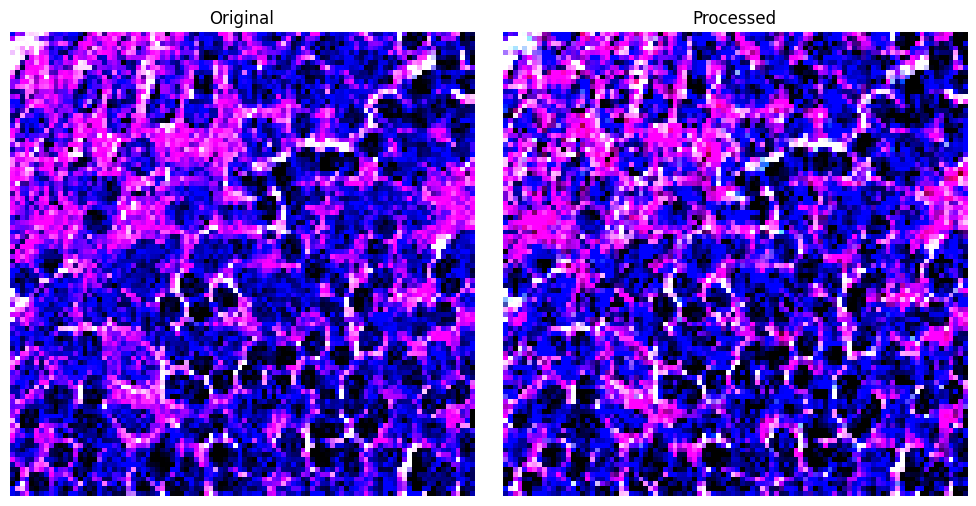

In [32]:
idx = 5
frame.plot_example(example=adversarial_dataset[idx][0], original=test_dataset[idx][0], denormalize=False)

Run evaluation of the base classifier on the adversarial dataset given by applying the attack over the clean test dataset

In [33]:
frame._evaluate_dataset(dataset=adversarial_dataset, classifier=frame.base_classifier, name="FGSM_no_defense")

Evaluating FGSM_no_defense dataset:   0%|          | 0/10 [00:00<?, ?it/s]

(0.2286,
 {'predictions': array([1, 0, 1, ..., 0, 0, 0]),
  'true_labels': array([0, 1, 0, ..., 1, 1, 1]),
  'confidences': array([0.18645729, 0.308848  , 1.5612204 , ..., 2.0186918 , 3.2425232 ,
         0.8959242 ], dtype=float32)})

Now, create another classifier which incorporates one or more defense strategies

In [34]:
defense_classifier = frame._build_classifier(
    defences=[GaussianSmoothing(sigma=1.0)]
)

Run evaluation on the dataset with adversarial examples using the defense classifier rather than the base classifier. The defense classifier has inside some defences

In [35]:
frame._evaluate_dataset(dataset=adversarial_dataset, classifier=defense_classifier, name="FGSM_gaussian_smoothing")

Evaluating FGSM_gaussian_smoothing dataset:   0%|          | 0/10 [00:00<?, ?it/s]

(0.4948,
 {'predictions': array([0, 0, 0, ..., 0, 0, 0]),
  'true_labels': array([0, 1, 0, ..., 1, 1, 1]),
  'confidences': array([1.2368088, 0.8494533, 1.4295254, ..., 1.8020245, 1.1285603,
         1.3126351], dtype=float32)})

Now, try the full pipeline. First instantiate a clean framework and then add attacks and defenses

---

# Main Pipeline

The framework is designed to run experiments on adversarial attacks and defenses. Our idea is to create a modular framework that allows users to easily add new attacks and defenses, and run experiments on them.

## General idea

The framework instantiates a base classifier, which is a ResNet18 model trained on the ImageNet dataset. It then evaluates the classifier on a clean test dataset. 
After that, depending on the attacks and defenses defined, it generates adversarial examples using the base classifier and evaluates them. 
Finally, it evaluates the adversarial examples using a defense classifier that incorporates one or more defense strategies.

## Running experiments

The run experiments works in this way:

- creates an empty object to store the metrics
- evaluates the clean test dataset with the base classifier
- loops over the defined attacks (you need to add them, check above)
- for each attack it generates a torch dataset applying the attack on each sample and then evaluates the adversarial crafted test set with base classifier
- then it loops over the defenses and for each it builds the classifier using only that defense and then it evaluates the adversarial crafted test set with the classifier having that defense as countermeasure.

## Statefulness

The framework is stateful, meaning that it keeps track of the current state of the experiments. Once an experiment is run, the metrics are stored in the framework object as well as the adversarial examples generated. In this way, running again the same experiment will not generate new adversarial examples, but will use the ones already generated. Moreover, when evaluating the performance of the classifier, if the results are already stored in the framework, it will not run the evaluation again, but will use the stored results, pushing them on the results dictionary which is then converted to a pandas dataframe.

## Notes
- >**Info**: The framework is designed to use only preprocessor defenses, which are applied to the input data before passing it to the classifier.
- >**MP3 Compression**: MP3 compression is tricky to add as a defense, because it needs to shrink the input dimension to either 1 or 2 channels (mono or stereo). Moreover, it needs to have just a single spatial dimension thus H and W need to be merged together. After compression, reshaping the input is not straightforward, so it is not implemented yet.

In [36]:
clean_frame = MyFramework(
    model=model.model,
    test_dataset=test_dataset,
    loss=nn.CrossEntropyLoss(),
    optimizer=optim.AdamW(model.model.parameters(), lr=1e-3),
    input_shape=(3, 96, 96),
    num_classes=2,
    channels_first=True,
    clip_values=None,
    batch_size=BATCH_SIZE
)

Add attacks

In [37]:
clean_frame.add_attack("FGSM (eps=0.2)", lambda clf: FastGradientMethod(estimator=clf, eps=0.2))
#clean_frame.add_attack("FGSM (eps=0.4)", lambda clf: FastGradientMethod(estimator=clf, eps=0.4))
#clean_frame.add_attack("PGD (eps=0.2)", lambda clf: ProjectedGradientDescent(estimator=clf, eps=0.2, max_iter=40))
#clean_frame.add_attack("PGD (eps=0.7)", lambda clf: ProjectedGradientDescent(estimator=clf, eps=0.3, max_iter=40))

Add defenses

In [38]:
defense_settings = {
    "verbose": False
}

In [39]:
clean_frame.add_defense("GaussianSmoothing (sigma=0.2)", lambda: GaussianSmoothing(sigma=0.2, **defense_settings))
clean_frame.add_defense("GaussianSmoothing (sigma=0.3)", lambda: GaussianSmoothing(sigma=0.3, **defense_settings))
clean_frame.add_defense("GaussianSmoothing (sigma=0.5)", lambda: GaussianSmoothing(sigma=0.5, **defense_settings))
#clean_frame.add_defense("JpegCompression (q=10)", lambda: JpegCompression(clip_values=(0,1), quality=10, channels_first=True, **defense_settings))
#clean_frame.add_defense("JpegCompression (q=50)", lambda: JpegCompression(clip_values=(0,1), quality=50, channels_first=True, **defense_settings))
#clean_frame.add_defense("JpegCompression (q=95)", lambda: JpegCompression(clip_values=(0,1), quality=95, channels_first=True, **defense_settings))
clean_frame.add_defense("SpatialSmoothing (w=3)", lambda: SpatialSmoothingPyTorch(window_size=3, channels_first=True))
clean_frame.add_defense("SpatialSmoothing (w=5)", lambda: SpatialSmoothingPyTorch(window_size=5, channels_first=True))
#clean_frame.add_defense("Total Variance Minimization", lambda: TotalVarMin(prob=0.3, max_iter=1, **defense_settings))
#clean_frame.add_defense("Thermometer Encoding", lambda: ThermometerEncoding(clip_values=(-3.0,3.0), channels_first=True))

In [40]:
results_df = clean_frame.run_experiments(output_file="results.csv")

Running clean experiment...
Computing results for clean


Evaluating clean dataset:   0%|          | 0/10 [00:00<?, ?it/s]


Processing attack: FGSM (eps=0.2)
Generating adversarial dataset for FGSM (eps=0.2)


Crafting adversarial (FastGradientMethod):   0%|          | 0/10 [00:00<?, ?it/s]

Computing results for FGSM (eps=0.2)_no_defense


...


Processing defense: SpatialSmoothing (w=3)
Computing results for none_SpatialSmoothing (w=3)


Evaluating none_SpatialSmoothing (w=3) dataset:   0%|          | 0/10 [00:00<?, ?it/s]


Processing defense: SpatialSmoothing (w=5)
Computing results for none_SpatialSmoothing (w=5)


Evaluating none_SpatialSmoothing (w=5) dataset:   0%|          | 0/10 [00:00<?, ?it/s]

Results saved to /kaggle/working/results.csv


In [41]:
results_df.sort_values(by="accuracy", ascending=False)

,attack,defense,accuracy
0,none,none,0.8518
7,none,GaussianSmoothing (sigma=0.2),0.8150
10,none,SpatialSmoothing (w=3),0.7730
8,none,GaussianSmoothing (sigma=0.3),0.7520
11,none,SpatialSmoothing (w=5),0.7352
9,none,GaussianSmoothing (sigma=0.5),0.5730
6,FGSM (eps=0.2),SpatialSmoothing (w=5),0.4362
5,FGSM (eps=0.2),SpatialSmoothing (w=3),0.3532
4,FGSM (eps=0.2),GaussianSmoothing (sigma=0.5),0.3440
3,FGSM (eps=0.2),GaussianSmoothing (sigma=0.3),0.2600


Accuray heatmap with defenses and attacks

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


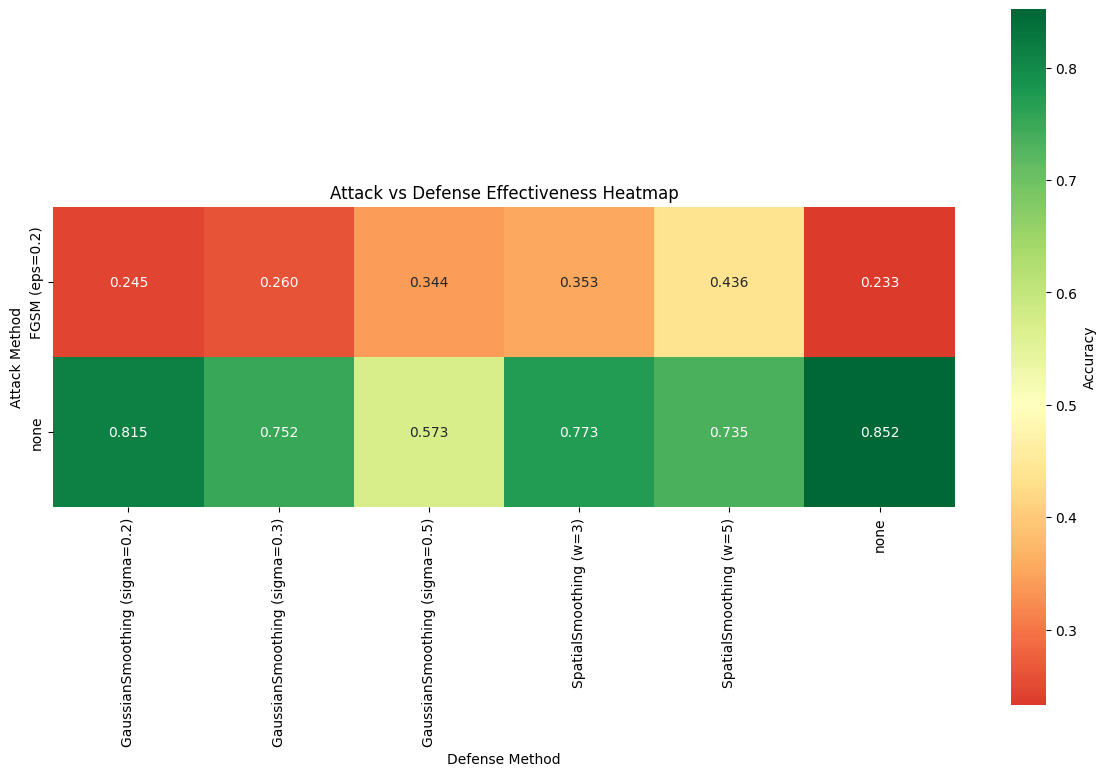

In [42]:
clean_frame.plot_accuracy_heatmap(results_df)

Robustness curves with accuracy, accuracy drop, defense performance radar and stacked performances

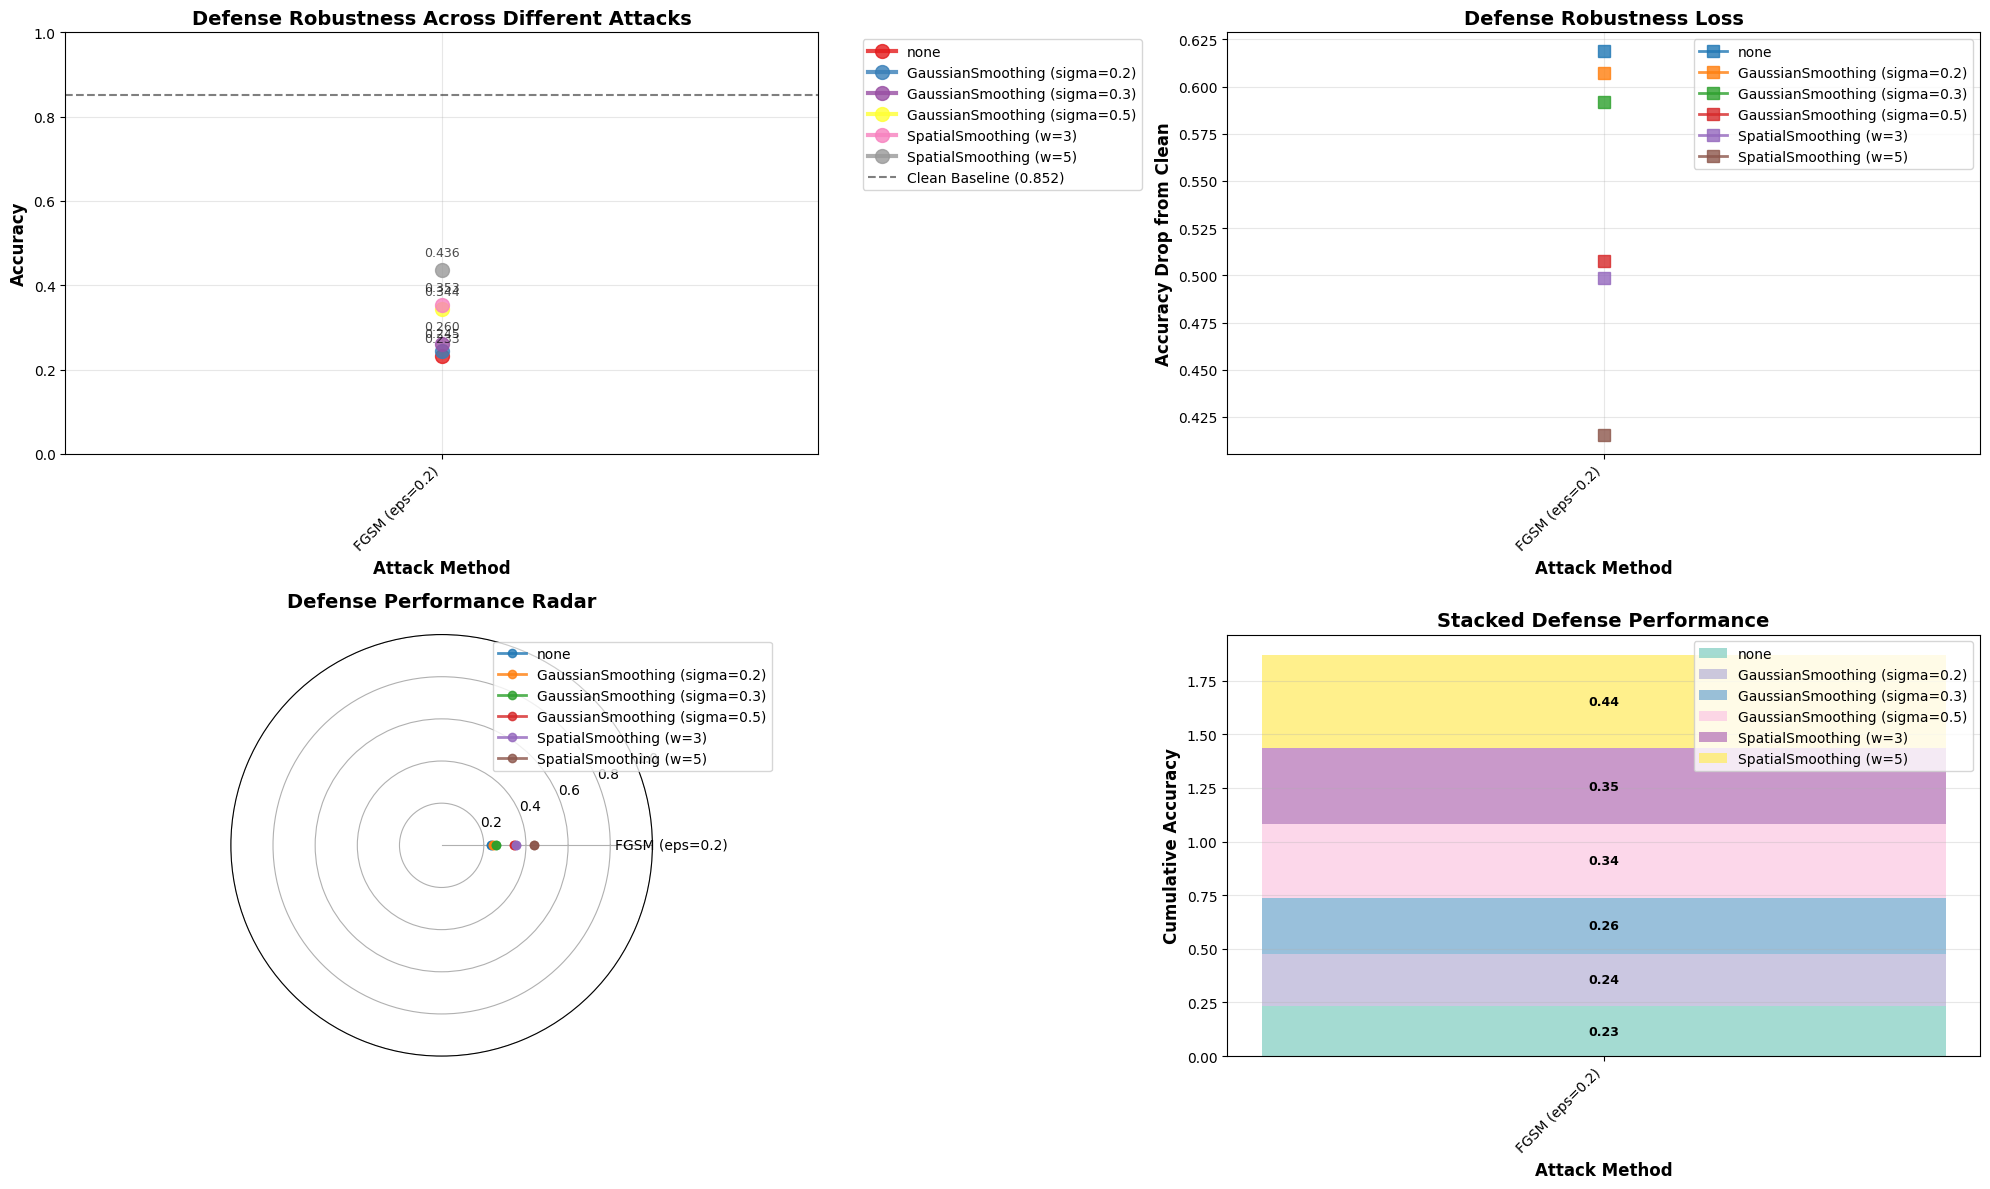


DEFENSE ROBUSTNESS SUMMARY

none:
  Mean Accuracy: 0.233 ± 0.000
  Range: [0.233, 0.233]
  Robustness Score: 0.274
  Most Robust Against: FGSM (eps=0.2) (0.233)
  Least Robust Against: FGSM (eps=0.2) (0.233)

GaussianSmoothing (sigma=0.2):
  Mean Accuracy: 0.245 ± 0.000
  Range: [0.245, 0.245]
  Robustness Score: 0.287
  Most Robust Against: FGSM (eps=0.2) (0.245)
  Least Robust Against: FGSM (eps=0.2) (0.245)

GaussianSmoothing (sigma=0.3):
  Mean Accuracy: 0.260 ± 0.000
  Range: [0.260, 0.260]
  Robustness Score: 0.305
  Most Robust Against: FGSM (eps=0.2) (0.260)
  Least Robust Against: FGSM (eps=0.2) (0.260)

GaussianSmoothing (sigma=0.5):
  Mean Accuracy: 0.344 ± 0.000
  Range: [0.344, 0.344]
  Robustness Score: 0.404
  Most Robust Against: FGSM (eps=0.2) (0.344)
  Least Robust Against: FGSM (eps=0.2) (0.344)

SpatialSmoothing (w=3):
  Mean Accuracy: 0.353 ± 0.000
  Range: [0.353, 0.353]
  Robustness Score: 0.415
  Most Robust Against: FGSM (eps=0.2) (0.353)
  Least Robust Agains

In [43]:
clean_frame.plot_defense_robustness_curves(results_df)

Which class suffers the most from the attacks based on each attack

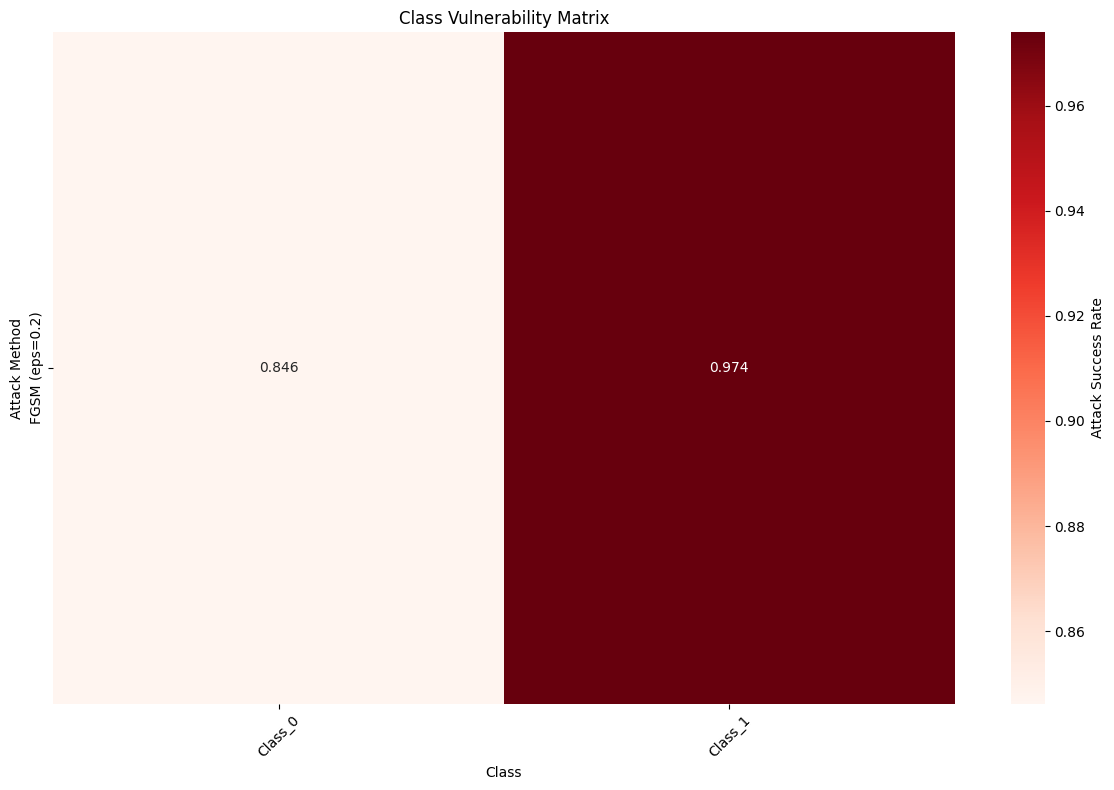

In [44]:
clean_frame.plot_class_vulnerability_matrix(results_df)

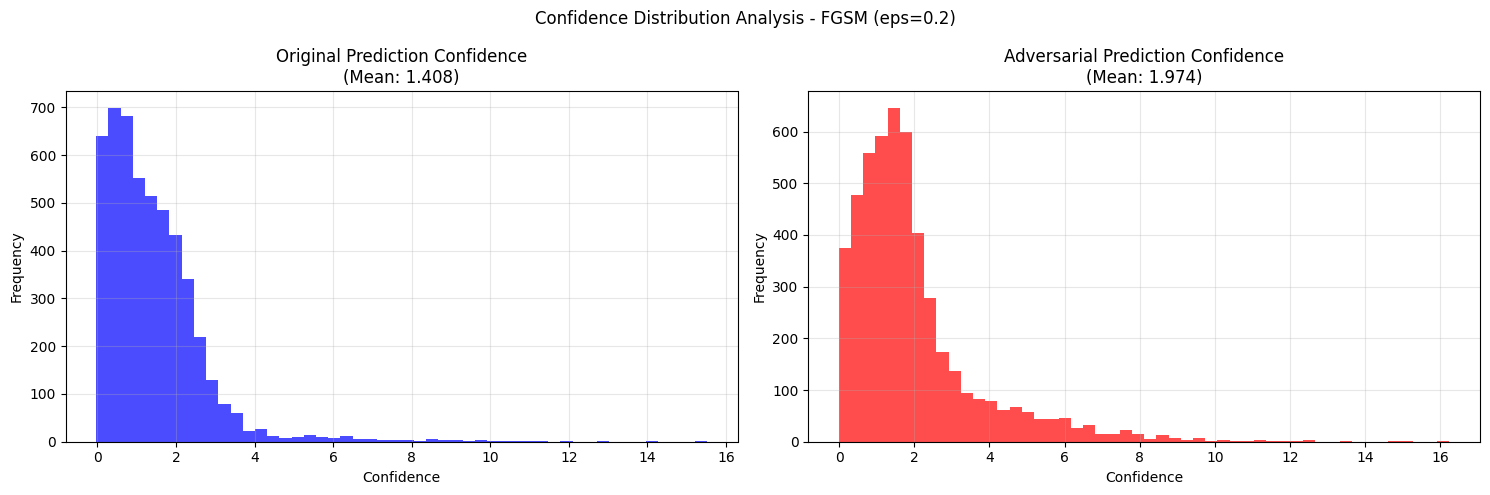

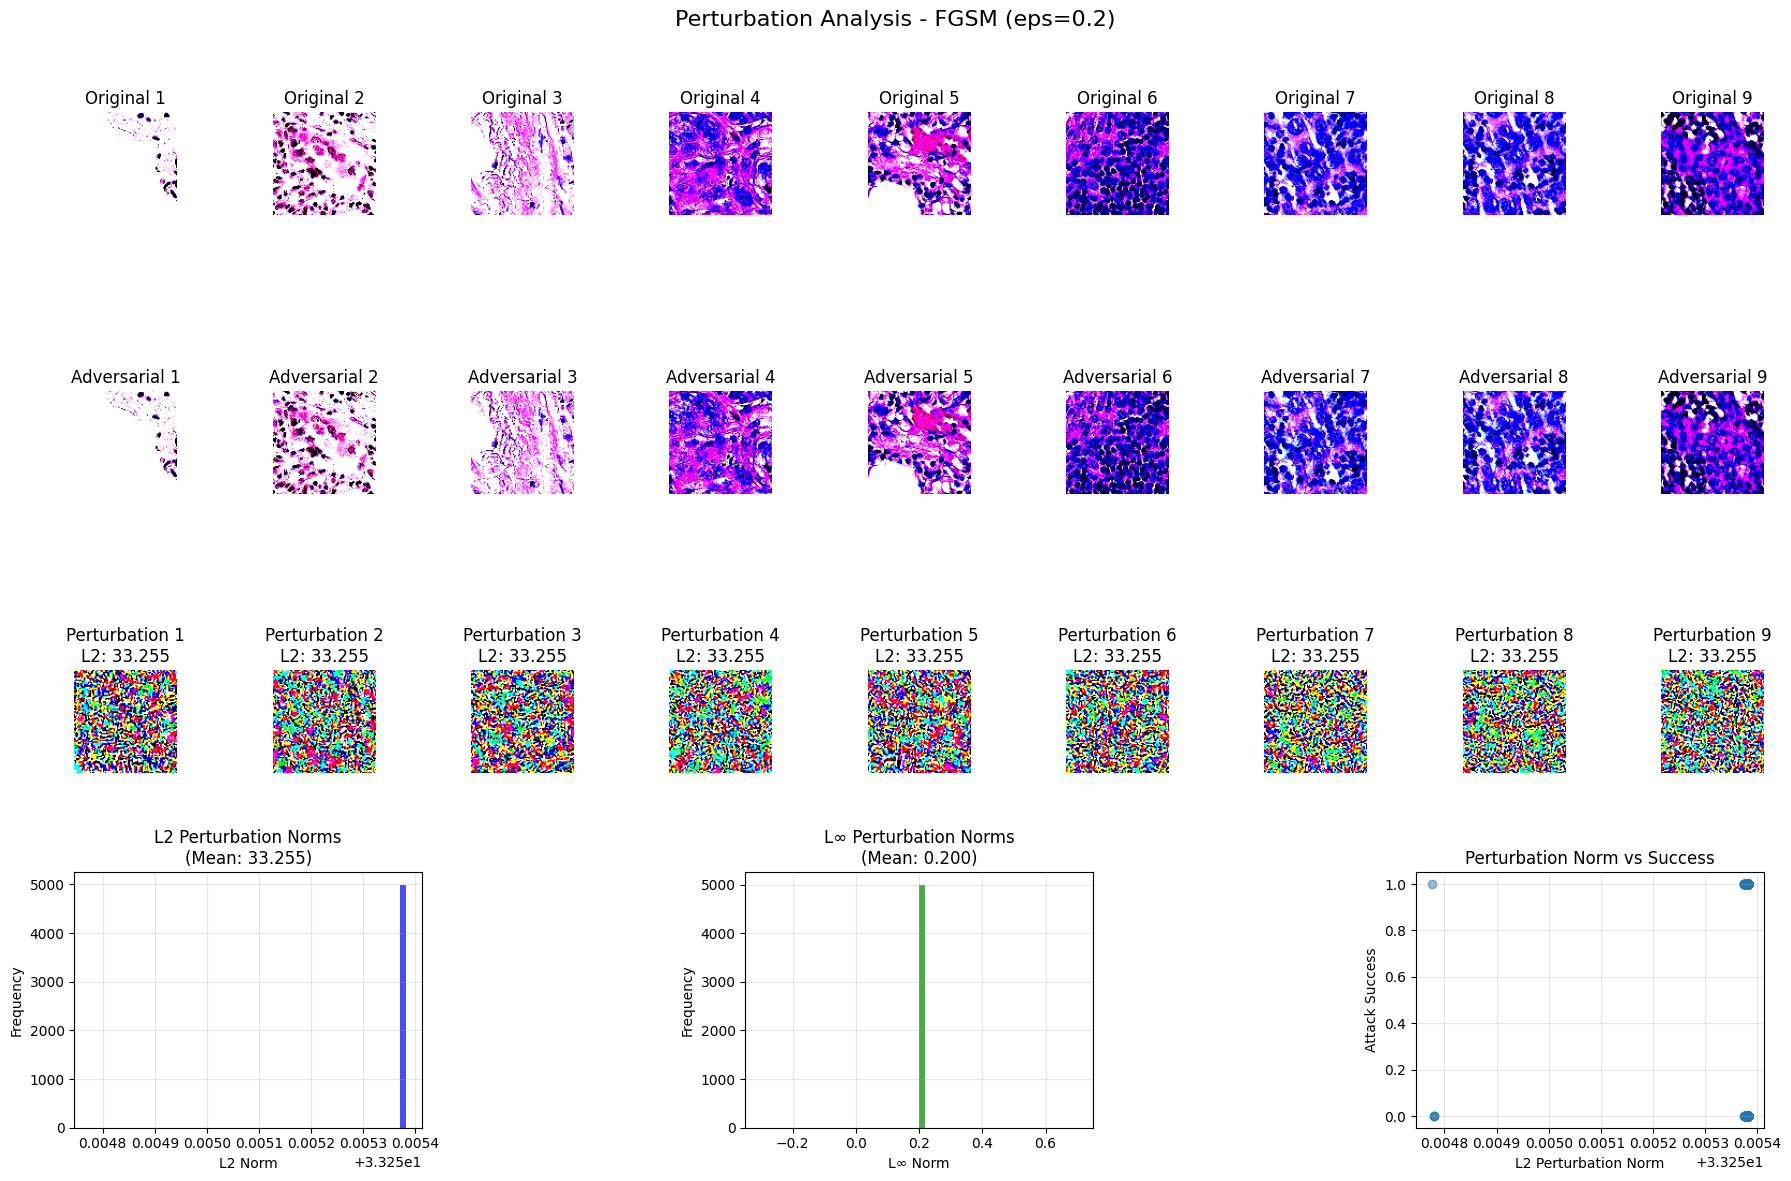

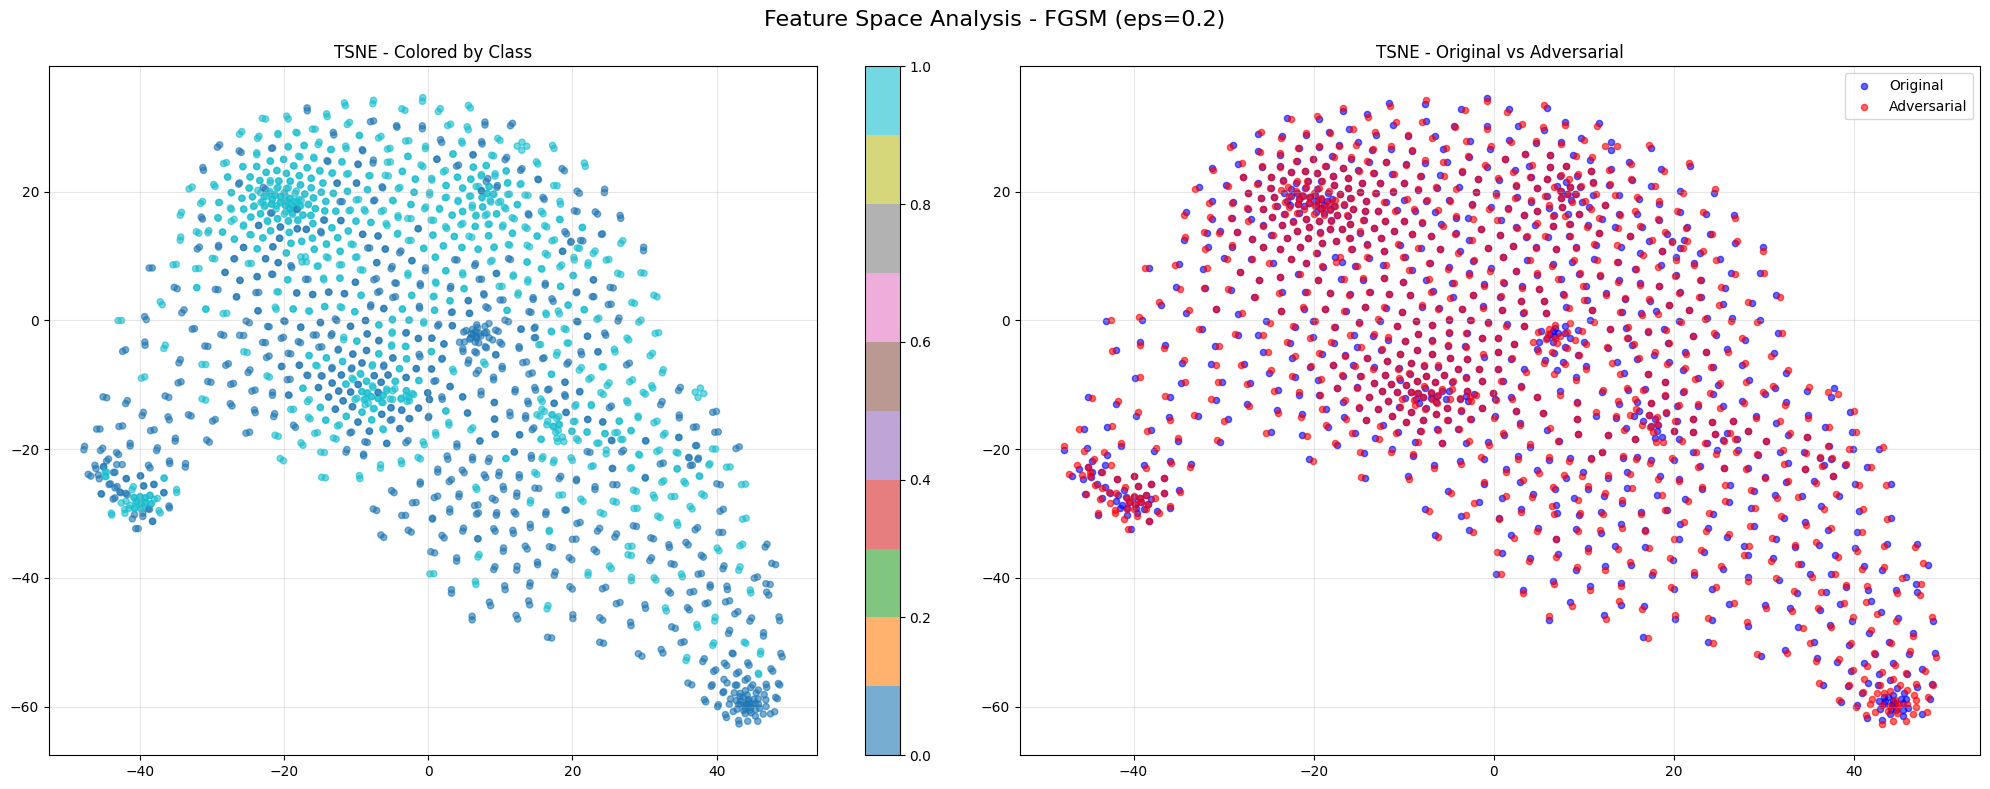

In [45]:
attack_names = [name for name in results_df['attack'].unique() if name != 'none']
for attack_name in attack_names:
    
    # Confidence distributions
    clean_frame.plot_confidence_distributions(attack_name)
    
    # Perturbation analysis
    clean_frame.plot_perturbation_analysis(attack_name)
    
    # Feature space analysis
    if len(clean_frame.detailed_results.get(attack_name, {}).get('original_images', [])) > 0:
        clean_frame.plot_feature_space_analysis(attack_name, method='tsne')